## Import libraries

In [1]:
import json
from typing import List
import os

from unstructured.partition.pdf import partition_pdf
from unstructured.chunking.title import chunk_by_title

from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv()

EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
assert EMBEDDING_MODEL is not None, "Missing EMBEDDING_MODEL in .env"

LLM = os.getenv("LLM")
assert LLM is not None, "Missing LLM MODEL in .env"

def get_int_env(name: str, default: int | None = None) -> int:
    value = os.getenv(name)

    if value is None:
        if default is None:
            raise RuntimeError(f"Missing required env var: {name}")
        return default

    try:
        return int(value)
    except ValueError:
        raise RuntimeError(f"Env var {name} must be an integer, got: {value}")
    
CHUNK_MAX_CHARS = get_int_env("CHUNK_MAX_CHARS", 2000)
CHUNK_AFTER_NCHARS = get_int_env("CHUNK_AFTER_NCHARS", 1500)
CHUNK_COMBINE_UNDER_NCHARS = get_int_env("CHUNK_COMBINE_UNDER_NCHARS", 1000)
MAX_IMAGES_PER_REQUEST = get_int_env("MAX_IMAGES_PER_REQUEST", 3)
MAX_SUMMARY_INPUT_CHARS = get_int_env("MAX_SUMMARY_INPUT_CHARS", 3000)
print_log = True


c:\Users\myngo\Downloads\_main\4\Thesis\Work\MultiModalRAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
LLM2 = get_int_env("LLM2", "gemma3:27b-cloud")

RuntimeError: Env var LLM2 must be an integer, got: gemma3:27b-cloud

In [ ]:
# %pip install -U tqdm ipywidgets
# %pip install pytesseract


## 1 - Partition PDFs into atomic elements

In [ ]:
def partition_document(file_path: str):
    """Extract elements from PDF using unstructured"""
    print(f"Partitioning document: {file_path}")
    
    elements = partition_pdf(
        filename=file_path,
        strategy="hi_res",
        infer_table_structure=True,
        extract_image_block_types=["Image"],
        extract_image_block_to_payload=True
    )
    print(f"Extracted {len(elements)} elements.")
    return elements 

### Try with file Attention is all you need pdf

In [ ]:
# file_path = "./docs/attention-is-all-you-need.pdf"
# elements = partition_document(file_path=file_path)


In [ ]:
# print(elements)
# el_types = set([str(type(el).__name__) for el in elements])
# for t in el_types:
#     print(t)


In [ ]:
# elements[15].to_dict()

In [ ]:
# images = [element for element in elements if element.category == 'Image']
# print(f"{len(images)} images.")

# images[0].to_dict()
# # can view image in code beautify

In [ ]:
# tables = [element for element in elements if element.category == 'Table']
# print(f"{len(tables)} tables.")
# tables[0].to_dict()
# # can view table in jsfiddle.net

## 2 - Chunking by titles

In [ ]:
def create_chunks_by_title(elements, max_chars, new_after_nchars, combine_under_nchars):
    """Create intelligent chunks using title-based strategy"""
    
    print("Creating chunks...")
    
    chunks = chunk_by_title(
        elements=elements,
        max_characters=max_chars,
        new_after_n_chars=new_after_nchars,
        combine_text_under_n_chars=combine_under_nchars
    )
    
    print(f"Created {len(chunks)} chunks")
    return chunks

In [ ]:
# chunks = create_chunks_by_title(elements)

In [ ]:
# print(chunks[4].to_dict())
# chunks[4].metadata.orig_elements[3].metadata.to_dict()


## 3 - Summarising chunks & create LangChain documents

In [ ]:
def separate_content_types(chunk):
    """Analyze what types of content are in a chunk"""
    content_data = {
        'text': chunk.text,
        'tables': [],
        'images': [],
        'types':['text']
    }
    
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = type(element).__name__
            
            if element_type == "Table":
                content_data['types'].append('table')
                table_html = getattr(element.metadata, 'text_as_html', element.text)
                content_data['tables'].append(table_html)
            
            elif element_type == "Image":
                if hasattr(element, 'metadata') and hasattr(element.metadata, 'image_base64'):
                    content_data['types'].append('image')
                    content_data['images'].append(element.metadata.image_base64)
    
    content_data['types'] = list(set(content_data['types']))
    return content_data


In [ ]:
def create_ai_enhanced_summary(text: str, tables: list[str], images: list[str]):
    """Create AI-enhanced summary for mixed content"""
    try:
        llm = ChatOllama(model=LLM, temperature=0)
        prompt_text = f"""
        You are creating a searchable description for document content retrieval.
        
        CONTENT TO ANALYZE:
        TEXT CONTENT: 
        {text}
        """
        
        if tables:
            prompt_text += "\nTABLES: \n"
            for i, table in enumerate(tables):
                prompt_text += f"Tables {i+1}: \n{table}\n"
                
        # prompt_text += """
        # YOUR TASK:
        # Generate a comprehensive, searchable description that covers:
        # 1. Key facts, numbers, and data points from the text and tables
        # 2. Main topics and concepts discussed
        # 3. Questions this content could answer
        # 4. Visual content analysis (charts, diagram, patterns in images)
        # 5. Alternative search terms users might use
        
        # Make it detailed and searchable - prioritize findability over brevity.
        
        # SEARCHABLE DESCRIPTION:
        # """
        
        
        # prompt_text += """
        # YOUR TASK:
        # Generate a description that covers:
        # 1. Main topics and concepts discussed
        # 2. Key facts, numbers, and data points from the text and tables
        # 3. Visual content analysis (charts, diagram, patterns in images)
        # 4. Alternative search terms users might use
        
        # Make it searchable - prioritize findability over brevity but no longer than 500 words.
        
        # SEARCHABLE DESCRIPTION:
        # """
        
        prompt_text += """
        YOUR TASK:
        Return ONLY one paragraph describing the document's key concepts. Be sure to include details of any tables or images if they are present. The paragraph should not be longer than 600 words.
        """
        
        message_content = [{"type":"text", "text":prompt_text}]
        
        for i, image_base64 in enumerate(images):
            if i < MAX_IMAGES_PER_REQUEST:
                message_content.append({
                    "type":"image_url",
                    "image_url":{"url":f"data:image/jpeg;base64,{image_base64}"}
                })
            
        messages = HumanMessage(content=message_content)
        response = llm.invoke([messages])
        
        return response.content
    except Exception as e:
        print(f"   Ai summary failed: {e}")
        summary = f"{text[:300]}..."
        if tables:
            summary += f" [Contains {len(tables)} tables.]"
        if images:
            summary += f" [Contains {len(images)} images.]"
        return summary
    
                

In [ ]:
def summarise_chunks(chunks):
    """Process all chunks with AI summaries"""
    print("Processing chunks with AI summaries...")
    
    langchain_documents = []
    total_chunks = len(chunks)
    
    for i, chunk in enumerate(chunks):
        current_chunk = i+1
        print(f"   Processing chunk {current_chunk}/{total_chunks}")
        
        content_data = separate_content_types(chunk=chunk)
        print(f"   Types found: {content_data['types']}")
        
        if content_data['tables'] or content_data['images']:
            print(f" Creating AI summary for mixed content....")
            try:
                enhanced_content = create_ai_enhanced_summary(
                    content_data['text'],
                    content_data['tables'],
                    content_data['images']
                )
                enhanced_content = enhanced_content[:MAX_SUMMARY_INPUT_CHARS]
                print(f"=> AI summary created successfully.")
                # print(f"Enhanced content preview: {enhanced_content[:200]}...")
                if print_log:
                    print(f"AI summary: {enhanced_content}")
            except Exception as e:
                print(f" Ai summary failed: {e}")
                enhanced_content = content_data['text']
        else: 
            print(f" Using raw text (no tables/images)")
            enhanced_content = content_data['text']
            
        doc = Document(
            page_content=enhanced_content,
            metadata={
                "original_content": json.dumps(
                    {
                        "raw_text": content_data['text'],
                        "tables_html": content_data['tables'],
                        "images_base64": content_data['images']
                    },
                    ensure_ascii=False
                )                
            }
        )  
        
        # print(doc)
              
        langchain_documents.append(doc)
        # print(langchain_documents)
        
    print(f"Processed {len(langchain_documents)} chunks.")
    return langchain_documents

In [ ]:
# processed_chunks = summarise_chunks(chunks=chunks)


In [ ]:
def export_chunks_to_json(chunks, filename="chunks_export.json"):
    """Export processed chunks to clean JSON format"""
    export_data = []
    
    for i, doc in enumerate(chunks):
        chunk_data = {
            "chunk_id": i+1,
            "enhanced_content": doc.page_content,
            "metadata": {
                "original_content": json.loads(doc.metadata.get("original_content", "{}"))
            }
        }
        export_data.append(chunk_data)
        
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)
    print(f"Exported {len(chunks)} chunks.")
    return export_data

# json_data = export_chunks_to_json(chunks=processed_chunks)

## 4 - Store in vectordb

In [ ]:
def create_vector_store(documents, persist_directory="db/chroma_db"):
    """Create and persist ChromaDB vector store"""
    print("Creating embeddings and storing in ChromaDB...")
    
    embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL)
    print("Creating vector store...")
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        persist_directory=persist_directory,
        collection_metadata={"hnsw:space":"cosine"}
    )
    
    print("Ok")
    return vector_store

In [ ]:
# db = create_vector_store(processed_chunks)

## 5 - Retrieve

In [ ]:
# query = "How is auto regressive in Transformer model architecture?"
# retriever = db.as_retriever(search_kwargs={"k":3})
# rag_chunks = retriever.invoke(query)

# export_chunks_to_json(chunks=rag_chunks, filename="rag_result.json")

## 6- Generate final answer

In [ ]:
def generate_final_answer(chunks, query):
    """Generate the final answer for user's question"""
    print(query)
    
    llm = ChatOllama(model="devstral-small-2:24b-cloud")
    prompt = f"""Answer the user question: "{query}". \nYou are provided the relevant documents below:"""

    for i, chunk in enumerate(chunks):
        prompt+=f"\n**Document {i+1}:\n"
        original = json.loads(chunk.metadata["original_content"])
        prompt+=f"\nTEXT:\n"
        prompt+=original["raw_text"]
        
        prompt_tables = original["tables_html"]
        if prompt_tables:
            prompt+=f"\nTABLES:\n"
            for j, table in enumerate(prompt_tables):
                prompt+=f"Table {j+1}:\n"
                prompt += table
    
    prompt+= f"""Please only use the above data to answer the question, but don't mention as "from Document x, y, etc". 
    If you don't have enough information to answer, just say you don't have enough information to answer the question.
    """
    message_content = [{"type":"text", "text":prompt}]
    
    
    prompt_images = []
    for i, chunk in enumerate(chunks):
        original = json.loads(chunk.metadata["original_content"])
        if len(prompt_images)<MAX_IMAGES_PER_REQUEST-1:
            chunk_images = original.get("images_base64", [])
            for img in chunk_images:
                prompt_images.append(img)

            
    for image_base64 in prompt_images:
        message_content.append({
            "type":"image_url",
            "image_url":{"url":f"data:image/jpeg;base64,{image_base64}"}
        })
        
    messages = HumanMessage(content=message_content)
    print([messages])
    final_response = llm.invoke([messages])
    return final_response
    
# answer = generate_final_answer(chunks=rag_chunks, query="Kiến trúc Transformer là gì?")
# print("---------ANSWER-----------\n")
# print(answer)


In [ ]:

#catch lỗi cho code ở trên


## Complete pipeline run

In [ ]:
print_log = True
def ingest(docs_path, db_path):
    elements = partition_document(docs_path)
    chunks = create_chunks_by_title(elements=elements, max_chars=CHUNK_MAX_CHARS, new_after_nchars=CHUNK_AFTER_NCHARS, combine_under_nchars=CHUNK_COMBINE_UNDER_NCHARS)
    processed_chunks = summarise_chunks(chunks=chunks)
    create_vector_store(processed_chunks, db_path)
    
def retrieve(query, db_path):
    embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL)
    db = Chroma(
        embedding_function=embedding_model,
        persist_directory=db_path,
        collection_metadata={"hnsw:space":"cosine"}
    )
    
    retriever = db.as_retriever(search_kwargs={"k":10})
    retrieved_chunks = retriever.invoke(query)
        
    if print_log:
        for i, chunk in enumerate(retrieved_chunks):
            print(f"\nChunk {i+1}")
            original = json.loads(chunk.metadata["original_content"])
            print(original["raw_text"])
            # print(chunk.page_content)
        
    answer = generate_final_answer(chunks=retrieved_chunks, query=query)
    return answer
    
        

### Ingest 

In [ ]:
# from pathlib import Path
# import os
# db_path = r"db\chroma_introduction_to_se"
# slide_folder = Path("docs/introduction_to_se")

# files = os.listdir(slide_folder)
# files_num = len(files)

# for i, pdf_path in enumerate(slide_folder.glob("*.pdf")):
#     print(f"\n\n🧋 {i+1}/{files_num} Processing file {pdf_path}...")
#     ingest(pdf_path, db_path)
    



🧋 1/14 Processing file docs\introduction_to_se\ActivityDiagram.pdf...
Partitioning document: docs\introduction_to_se\ActivityDiagram.pdf


Loading weights: 100%|██████████| 367/367 [00:00<00:00, 953.10it/s, Materializing param=model.query_position_embeddings.weight]                             


Extracted 58 elements.
Creating chunks...
Created 4 chunks
Processing chunks with AI summaries...
   Processing chunk 1/4
   Types found: ['text', 'image']
 Creating AI summary for mixed content....
=> AI summary created successfully.
AI summary: This document outlines the **UML Activity Diagram**, a behavioral modeling tool used to visualize workflows, business processes, and object activities within systems. The diagram represents **activities, actions, and data/control flows**, breaking down complex operations into sequential or parallel steps. Key elements include **Start and End Nodes** (marked by filled and hollow circles, respectively), **Action Nodes** (rectangles like "action1"), **Object Nodes** (e.g., "ObjectNode1"), and **Decision Nodes** (diamonds branching based on conditions such as `[cond1]`, `[cond2]`, or `[cond3]`), which direct flow to alternative actions. A **Merge Node** consolidates multiple paths back into a single flow without synchronization. The provided image

## Test with query


Chunk 1
• Training - people want to learn more;

• Responsibility.

9

Motivating people - Personality types

The needs hierarchy is almost certainly an over- simplification of motivation in practice. Motivation should also take into account different personality types:

• Task-oriented;

• Self-oriented;

• Interaction-oriented.

10

Motivating people - Personality types

Task-oriented

• The motivation for doing the work is the work itself;

Self-oriented

• The work is a means to an end which is the achievement of individual goals - e.g. to get rich, to play tennis, to travel etc.;

Interaction-oriented

• The principal motivation is the presence and actions of co- workers. People go to work because they like to go to work.

11

Chunk 2
6

Motivating people

An important role of a manager is to motivate the people

working on a project.

Motivation is a complex issue but it appears that there are different types of motivation based on:

• Basic needs (e.g. food, sleep, etc.);

• Pe
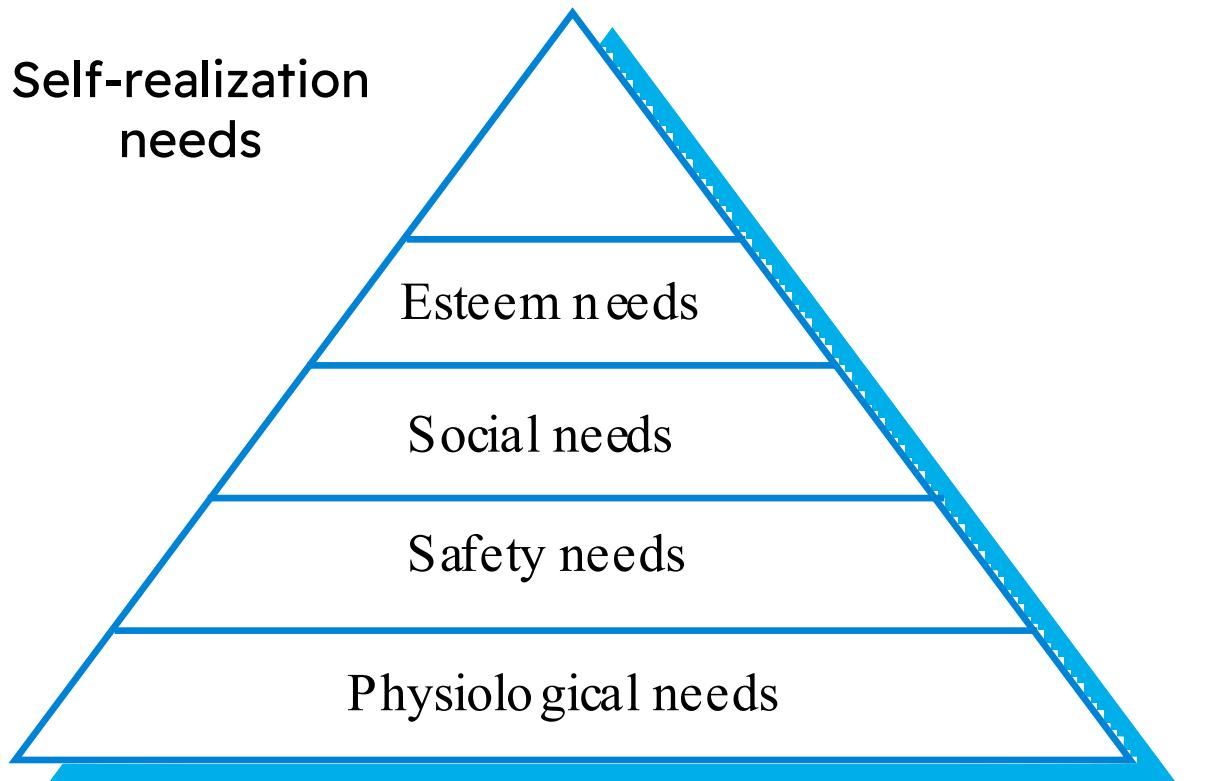
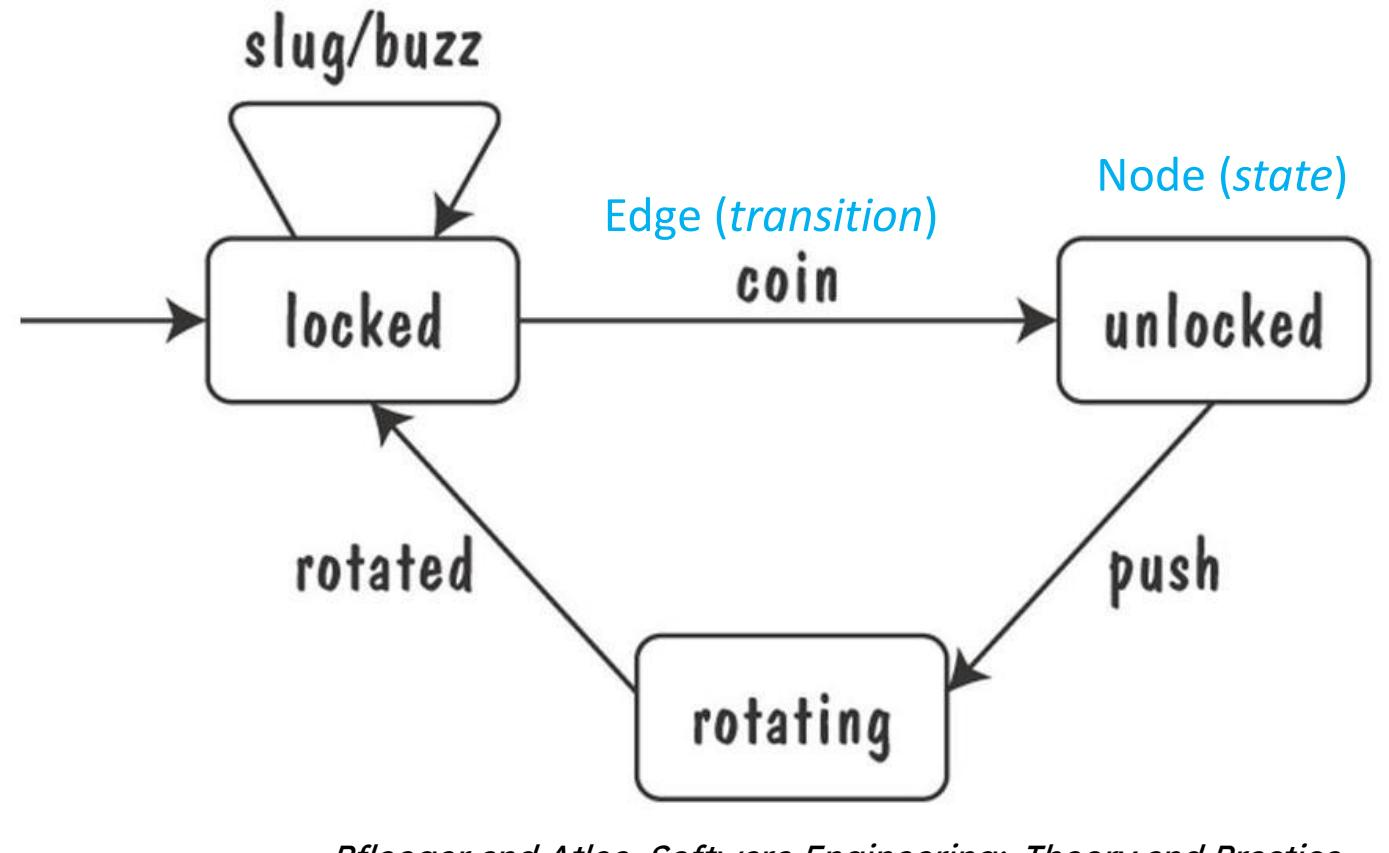
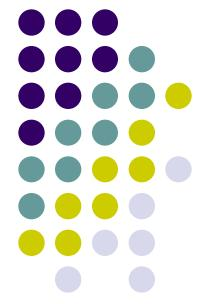
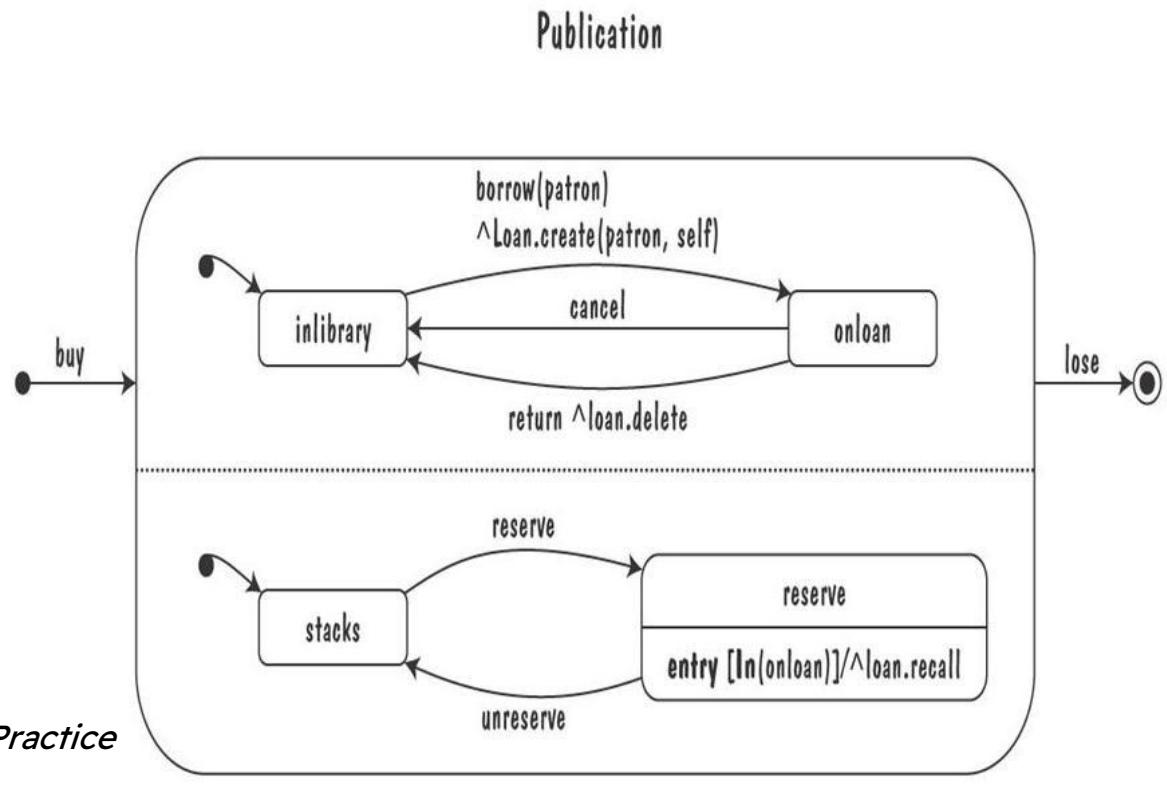

In [ ]:
print_log = True
# query = "Theo công văn của BTTTT 2013, có bao nhiêu yêu cầu phi chức năng chung cho các hệ thống thông tin cung cấp dịch vụ công trực tuyến?"
# query = "What are the Course Learning Outcomes in the course Introduction to Software Engineering?"
# query = "Có bao nhiêu loại nút trong sơ đồ UML?"
query = "Các loại động lực thường dựa trên những vấn đề nào?"
answer = retrieve(query=query, db_path="db/chroma_introduction_to_se")
print(answer)